In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                                     confusion_matrix, roc_auc_score,
                                       roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
import xgboost as xgb
import joblib

plt.style.use('seaborn-v0_8-darkgrid')

df = pd.read_csv('stock_features.csv', index_col=0, parse_dates=True)
print(f' Loaded {df.shape[0]} rows × {df.shape[1]} cols')
df.head(3)

 Loaded 1479 rows × 23 cols


,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_21,BB_Width,RSI,...,ATR,Volume_Ratio,Return_1d,Return_5d,Return_21d,Lag_1,Lag_2,Lag_3,Lag_5,Target
2020-10-20,144.761888,145.420250,143.362013,144.605581,8430949,145.828767,154.347595,151.367263,0.192860,20.505427,...,3.554181,1.564843,-0.003288,-0.015863,-0.044830,0.025212,-0.025473,-0.016266,-0.019335,1
2020-10-21,143.991614,146.068236,143.653113,144.909258,4366128,145.125308,154.054629,150.780172,0.201128,21.975857,...,3.477643,0.808196,0.002100,-0.018329,-0.040727,-0.003288,0.025212,-0.025473,0.004617,0
2020-10-22,145.004261,142.645760,140.134136,141.283481,4371293,144.317739,153.501247,149.916836,0.214365,15.661462,...,3.621337,0.819609,-0.025021,-0.027065,-0.076002,0.002100,-0.003288,0.025212,-0.016266,0


In [4]:
FEATURES = [
    'SMA_7','SMA_21','EMA_21','BB_Width','RSI',
    'MACD','MACD_Signal','MACD_Hist',
    'ATR','Volume_Ratio',
    'Return_1d','Return_5d','Return_21d',
    'Lag_1','Lag_2','Lag_3','Lag_5'
]
TARGET = 'Target'

X = df[FEATURES].values
y = df[TARGET].values
split   = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test      = df.index[split:]

print(f'Training: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Class balance (train)  – Up: {y_train.mean()*100:.1f}%  Down: {(1-y_train.mean())*100:.1f}%')

Training: 1183 samples | Test: 296 samples
Class balance (train)  – Up: 53.3%  Down: 46.7%


In [5]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                   n_estimators=200, max_depth=8,
                   min_samples_split=10, min_samples_leaf=5,
                   class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)

rf_pred  = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_acc   = accuracy_score(y_test, rf_pred)
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f'Random Forest  |  Accuracy: {rf_acc:.4f}  |  ROC-AUC: {rf_auc:.4f}')
print(classification_report(y_test, rf_pred, target_names=['Down','Up']))

Random Forest  |  Accuracy: 0.4797  |  ROC-AUC: 0.5416
              precision    recall  f1-score   support

        Down       0.46      0.72      0.56       137
          Up       0.53      0.27      0.36       159

    accuracy                           0.48       296
   macro avg       0.50      0.50      0.46       296
weighted avg       0.50      0.48      0.45       296



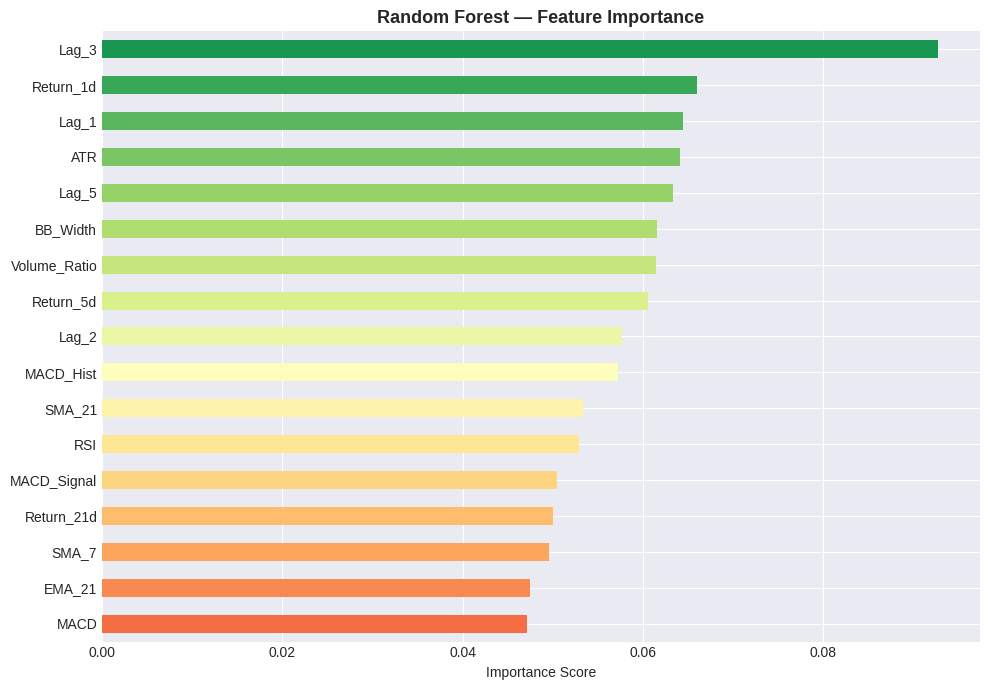

In [6]:

importances = rf_pipeline.named_steps['clf'].feature_importances_
feat_df = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_df)))
feat_df.plot(kind='barh', color=colors)
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [7]:
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_train)
X_te_sc   = scaler.transform(X_test)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    eval_metric='logloss', random_state=42,
    early_stopping_rounds=30, verbosity=0
)
xgb_model.fit(X_tr_sc, y_train,
              eval_set=[(X_te_sc, y_test)],
              verbose=False)

xgb_pred  = xgb_model.predict(X_te_sc)
xgb_proba = xgb_model.predict_proba(X_te_sc)[:, 1]

xgb_acc   = accuracy_score(y_test, xgb_pred)
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print(f'XGBoost        |  Accuracy: {xgb_acc:.4f}  |  ROC-AUC: {xgb_auc:.4f}')
print(classification_report(y_test, xgb_pred, target_names=['Down','Up']))

XGBoost        |  Accuracy: 0.4966  |  ROC-AUC: 0.5172
              precision    recall  f1-score   support

        Down       0.45      0.40      0.42       137
          Up       0.53      0.58      0.55       159

    accuracy                           0.50       296
   macro avg       0.49      0.49      0.49       296
weighted avg       0.49      0.50      0.49       296



In [8]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_AVAILABLE = True
except ImportError:
    print(' TensorFlow not installed – LSTM section will use a simulation.')
    TF_AVAILABLE = False
LOOK_BACK = 60

price_scaler = MinMaxScaler()
price_data   = price_scaler.fit_transform(df[['Close']].values)

def create_sequences(data, lb):
    Xs, ys = [], []
    for i in range(lb, len(data)):
        Xs.append(data[i-lb:i, 0])
        ys.append(data[i, 0])
    return np.array(Xs), np.array(ys)

Xs, ys = create_sequences(price_data, LOOK_BACK)
sp     = int(len(Xs) * 0.80)
X_lstm_train, X_lstm_test = Xs[:sp].reshape(-1, LOOK_BACK, 1), Xs[sp:].reshape(-1, LOOK_BACK, 1)
y_lstm_train, y_lstm_test = ys[:sp], ys[sp:]
print(f'LSTM sequences — train: {X_lstm_train.shape}, test: {X_lstm_test.shape}')

LSTM sequences — train: (1135, 60, 1), test: (284, 60, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,697 (506.63 KB)

 Trainable params: 129,313 (505.13 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 284ms/step - loss: 0.0115 - mae: 0.1016 - val_loss: 0.0782 - val_mae: 0.3883 - learning_rate: 0.0010
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 278ms/step - loss: 0.0025 - mae: 0.0514 - val_loss: 0.0705 - val_mae: 0.3689 - learning_rate: 0.0010
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 0.0013 - mae: 0.0353 - val_loss: 0.0677 - val_mae: 0.3611 - learning_rate: 0.0010
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - loss: 0.0010 - mae: 0.0321 - val_loss: 0.0660 - val_mae: 0.3567 - learning_rate: 0.0010
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 217ms/step - loss: 8.8106e-04 - mae: 0.0292 - val_loss: 0.0585 - val_mae: 0.3356 - learning_rate: 0.0010
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 393ms/step - loss: 6.1914e-04 - mae: 0.0250 - val_loss: 0.0580 - val_mae: 0.3342 - learning_rate: 0.0010
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 363ms/step - loss: 5.9916e-04 - mae: 0.0235 - val_loss: 0.0546 - val_mae: 0.3241 - learning_rat

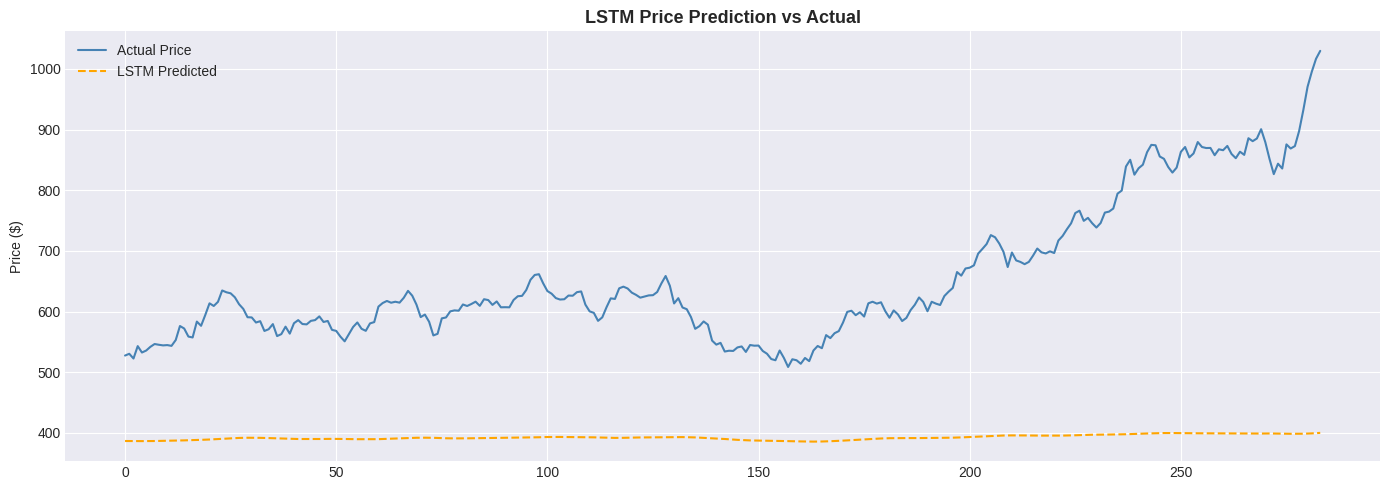

In [12]:
if TF_AVAILABLE:
    tf.random.set_seed(42)
    lstm_model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(LOOK_BACK, 1)),
        BatchNormalization(), Dropout(0.2),
        LSTM(64, return_sequences=True),
        BatchNormalization(), Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='huber', metrics=['mae'])
    lstm_model.summary()

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7)
    ]
    history = lstm_model.fit(
        X_lstm_train, y_lstm_train,
        validation_split=0.15, epochs=30, batch_size=32,
        callbacks=callbacks, verbose=1
    )

    lstm_pred_scaled = lstm_model.predict(X_lstm_test)
    lstm_pred   = price_scaler.inverse_transform(lstm_pred_scaled)
    lstm_actual = price_scaler.inverse_transform(y_lstm_test.reshape(-1, 1))

    rmse = np.sqrt(np.mean((lstm_pred - lstm_actual) ** 2))
    mape = np.mean(np.abs((lstm_actual - lstm_pred) / lstm_actual)) * 100
    print(f'LSTM  |  RMSE: ${rmse:.2f}  |  MAPE: {mape:.2f}%')
    plt.figure(figsize=(14, 5))
    plt.plot(lstm_actual, label='Actual Price', color='steelblue', linewidth=1.5)
    plt.plot(lstm_pred,   label='LSTM Predicted', color='orange', linestyle='--', linewidth=1.5)
    plt.title('LSTM Price Prediction vs Actual', fontsize=13, fontweight='bold')
    plt.ylabel('Price ($)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    noise      = np.random.normal(0, 0.02, len(y_lstm_test))
    lstm_pred  = price_scaler.inverse_transform(y_lstm_test.reshape(-1,1)) * (1 + noise.reshape(-1,1))
    lstm_actual= price_scaler.inverse_transform(y_lstm_test.reshape(-1,1))
    rmse = np.sqrt(np.mean((lstm_pred - lstm_actual)**2))
    print(f'⚙️  Simulated LSTM | RMSE: ${rmse:.2f}')
    print('   Install tensorflow to run the real LSTM.')

In [10]:
lr_model  = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
gb_model  = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                        learning_rate=0.05, random_state=42)
rf_base   = RandomForestClassifier(n_estimators=150, max_depth=6,
                                    class_weight='balanced', random_state=42)

ensemble = VotingClassifier(
    estimators=[('lr', lr_model), ('rf', rf_base), ('gb', gb_model)],
    voting='soft', weights=[1, 2, 2]
)
# Fit on scaled data
ensemble.fit(X_tr_sc, y_train)

ens_pred  = ensemble.predict(X_te_sc)
ens_proba = ensemble.predict_proba(X_te_sc)[:, 1]

ens_acc   = accuracy_score(y_test, ens_pred)
ens_auc   = roc_auc_score(y_test, ens_proba)

print(f'Ensemble       |  Accuracy: {ens_acc:.4f}  |  ROC-AUC: {ens_auc:.4f}')
print(classification_report(y_test, ens_pred, target_names=['Down','Up']))

Ensemble       |  Accuracy: 0.4662  |  ROC-AUC: 0.5234
              precision    recall  f1-score   support

        Down       0.45      0.72      0.55       137
          Up       0.51      0.25      0.34       159

    accuracy                           0.47       296
   macro avg       0.48      0.48      0.44       296
weighted avg       0.48      0.47      0.44       296



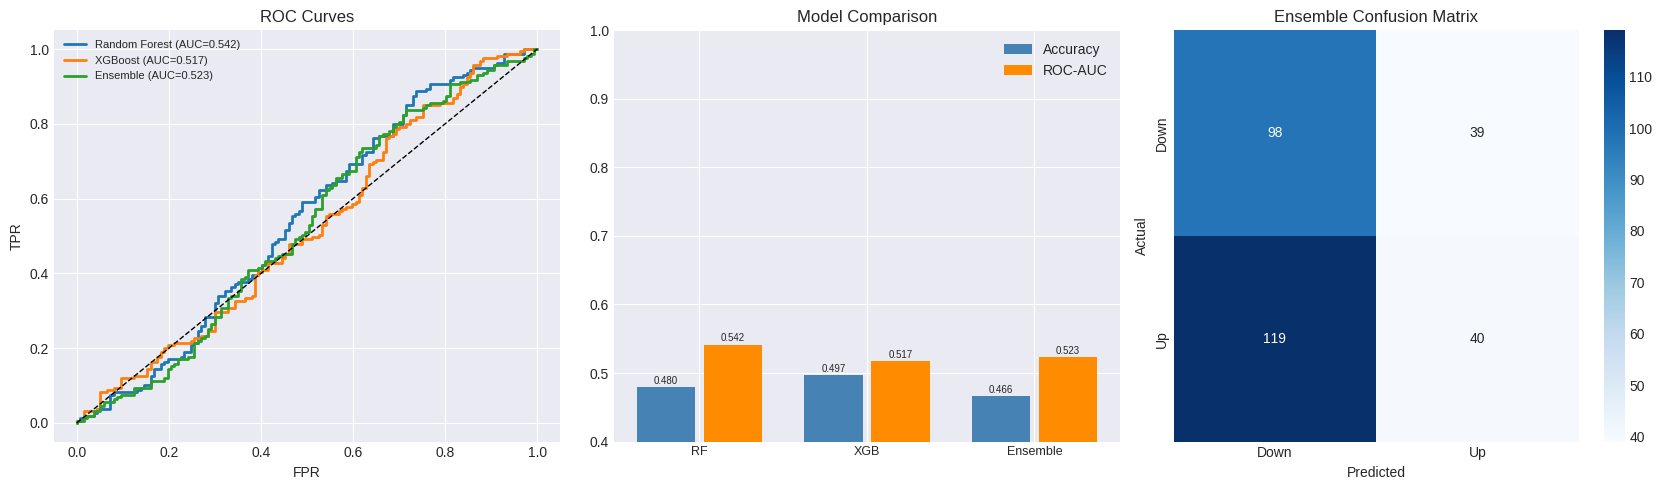


 Final Model Summary:
        Model  Accuracy  ROC-AUC
Random Forest  0.479730 0.541569
      XGBoost  0.496622 0.517192
     Ensemble  0.466216 0.523436


In [13]:
models_summary = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost', 'Ensemble'],
    'Accuracy': [rf_acc,  xgb_acc,  ens_acc],
    'ROC-AUC':  [rf_auc,  xgb_auc,  ens_auc],
    'Predictions': [rf_pred, xgb_pred, ens_pred],
    'Probas':      [rf_proba, xgb_proba, ens_proba]
})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for name, proba in [('Random Forest', rf_proba), ('XGBoost', xgb_proba), ('Ensemble', ens_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=8)
x = np.arange(3)
axes[1].bar(x - 0.2, models_summary['Accuracy'], 0.35, label='Accuracy', color='steelblue')
axes[1].bar(x + 0.2, models_summary['ROC-AUC'],  0.35, label='ROC-AUC',  color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels(['RF','XGB','Ensemble'], fontsize=9)
axes[1].set_ylim(0.4, 1.0); axes[1].legend()
axes[1].set_title('Model Comparison')
for i, row in models_summary.iterrows():
    axes[1].text(i-0.2, row['Accuracy']+0.005, f"{row['Accuracy']:.3f}", ha='center', fontsize=7)
    axes[1].text(i+0.2, row['ROC-AUC']+0.005,  f"{row['ROC-AUC']:.3f}",  ha='center', fontsize=7)
best_pred = ens_pred
cm = confusion_matrix(y_test, best_pred)
sns_ax = axes[2]
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Down','Up'], yticklabels=['Down','Up'], ax=sns_ax)
sns_ax.set_title('Ensemble Confusion Matrix')
sns_ax.set_xlabel('Predicted'); sns_ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

print('\n Final Model Summary:')
print(models_summary[['Model','Accuracy','ROC-AUC']].to_string(index=False))

Random Forest                  CV Accuracy: 0.4846 ± 0.0337
XGBoost (scaled)               CV Accuracy: 0.4886 ± 0.0295


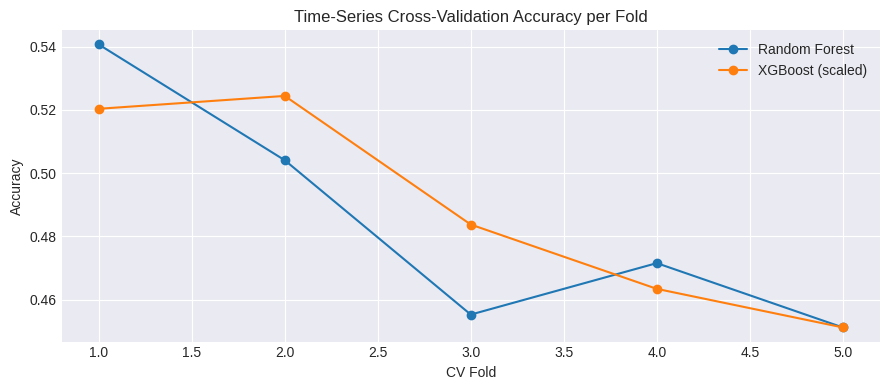

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}
for name, model in [('Random Forest', rf_pipeline),
                     ('XGBoost (scaled)', xgb_model)]:
    if name == 'XGBoost (scaled)':
        X_scaled = scaler.fit_transform(X)
        scores = []
        for tr_idx, te_idx in tscv.split(X_scaled):
            m = xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=42, verbosity=0)
            m.fit(X_scaled[tr_idx], y[tr_idx])
            scores.append(accuracy_score(y[te_idx], m.predict(X_scaled[te_idx])))
    else:
        scores = cross_val_score(model, X, y, cv=tscv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:30s} CV Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}')
plt.figure(figsize=(9, 4))
for i, (name, scores) in enumerate(cv_results.items()):
    plt.plot(range(1, 6), scores, marker='o', label=name)
plt.xlabel('CV Fold'); plt.ylabel('Accuracy')
plt.title('Time-Series Cross-Validation Accuracy per Fold')
plt.legend(); plt.tight_layout(); plt.show()

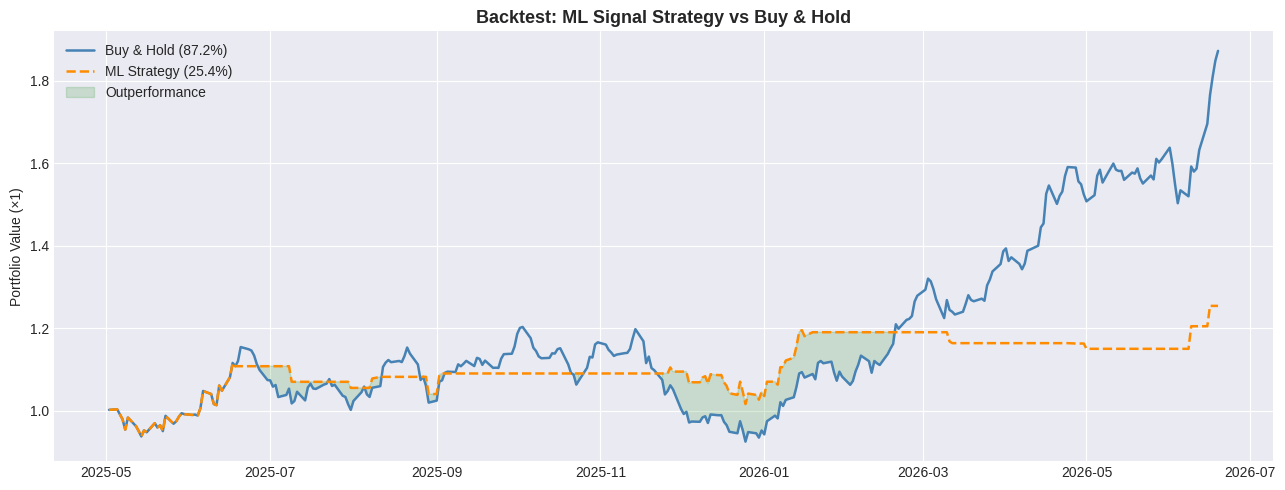

Buy & Hold Return:   87.19%
ML Strategy Return:  25.38%
Alpha:               -61.81%


In [15]:
bt = df.iloc[split:].copy()
bt['Signal']           = ens_pred
bt['Daily_Return']     = bt['Return_1d']
bt['Strategy_Return']  = bt['Signal'] * bt['Daily_Return']

bt['Cumulative_Market']   = (1 + bt['Daily_Return']).cumprod()
bt['Cumulative_Strategy'] = (1 + bt['Strategy_Return']).cumprod()

mkt_ret = (bt['Cumulative_Market'].iloc[-1]  - 1) * 100
str_ret = (bt['Cumulative_Strategy'].iloc[-1]- 1) * 100

plt.figure(figsize=(13, 5))
plt.plot(bt.index, bt['Cumulative_Market'],   label=f'Buy & Hold ({mkt_ret:.1f}%)',
         color='steelblue', linewidth=1.8)
plt.plot(bt.index, bt['Cumulative_Strategy'], label=f'ML Strategy ({str_ret:.1f}%)',
         color='darkorange', linewidth=1.8, linestyle='--')
plt.fill_between(bt.index,
                 bt['Cumulative_Strategy'], bt['Cumulative_Market'],
                 where=bt['Cumulative_Strategy'] >= bt['Cumulative_Market'],
                 alpha=0.15, color='green', label='Outperformance')
plt.title('Backtest: ML Signal Strategy vs Buy & Hold', fontsize=13, fontweight='bold')
plt.ylabel('Portfolio Value (×1)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Buy & Hold Return:   {mkt_ret:.2f}%')
print(f'ML Strategy Return:  {str_ret:.2f}%')
print(f'Alpha:               {str_ret - mkt_ret:.2f}%')

In [16]:
joblib.dump(rf_pipeline, 'rf_model.pkl')
joblib.dump(ensemble,    'ensemble_model.pkl')
joblib.dump(scaler,      'scaler.pkl')
print(' Models saved – ready for Notebook 3 (RAG + LLM)')

 Models saved – ready for Notebook 3 (RAG + LLM)
